In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# First combining the raw data into csv format, for pandas processing.

xls = pd.ExcelFile("../data/raw/online_retail_II.xlsx")

# .sheet_names shows every tab inside the workbook
print("Sheets found: ", xls.sheet_names)

# loading each sheet individually into its own Dataframe
df_2009_2010 = pd.read_excel(xls, sheet_name = "Year 2009-2010")
df_2010_2011 = pd.read_excel(xls, sheet_name = "Year 2010-2011")

print("Sheet 1 shape:", df_2009_2010.shape)
print("Sheet 2 shape:", df_2010_2011.shape)

# Now, confirming that both sheets have the same columns before combining them.
print("Same columns?", list(df_2009_2010.columns) == list(df_2010_2011.columns))

# now, stacking them on top of each other into one combined table.
combined = pd.concat([df_2009_2010, df_2010_2011], ignore_index = True)

print("Combined shape:", combined.shape)    # # Should equal sheet1_rows + sheet2_rows exactly

# Now, saving the concatinated table into a single CSV, this file will be responsible for furhter analysis.
combined.to_csv("../data/raw/online_retail_II_combined.csv", index = False)
print("Saved combined CSV.")


Sheets found:  ['Year 2009-2010', 'Year 2010-2011']
Sheet 1 shape: (525461, 8)
Sheet 2 shape: (541910, 8)
Same columns? True
Combined shape: (1067371, 8)
Saved combined CSV.


In [ ]:
# Loading the raw file - before moving to the cleaning part.
raw = pd.read_csv("../data/raw/online_retail_II_combined.csv")

# .shape tells you (number of rows, number of columns) - the very first thing to check
print("Shape (rows, columns):", raw.shape)

print(raw.head())

# .dtypes shows what type of data it has.
print("\n--- Column datatypes ---")
print(raw.dtypes)

# Now, checking the empty or null values.
print("\n--- Missing (null) values per column ---")
print(raw.isnull().sum())

# .duplicated() flags a row as True if it's an EXACT copy of an earlier row
print("\nFully duplicated rows:", raw.duplicated().sum())

# .nunique() counts how many DIFFERENT values exist in a column
print("\n--- Unique value counts ---")
print("Unique invoices:", raw["Invoice"].nunique())
print("Unique products (StockCode):", raw["StockCode"].nunique())
print("Unique countries:", raw["Country"].nunique())

# .describe() gives summary statistics for NUMERIC columns only:
# count, mean, std (spread), min, 25%/50%/75% (percentiles), max
print("\n--- Summary statistics for numeric columns ---")
print(raw[["Quantity", "Price"]].describe())

# Now, looking at how many rows have "impossible" values.
print("\n--- Suspicious value counts ---")
print("Rows with negative Quantity (likely returns):", (raw["Quantity"] < 0).sum())
print("Rows with Price <= 0 (data errors / giveaways):", (raw["Price"] <= 0).sum())

# "Cancellations" in this dataset are marked by Invoice numbers starting
# with the letter 'C' — this is a quirk specific to THIS dataset, something only learn by reading the dataset's documentation or noticing the pattern. 
cancellations = raw["Invoice"].astype(str).str.startswith("C")
print("Cancellation invoices:", cancellations.sum())

# Now, inspecting some rows of these problem rows.
print("\n--- Example: a cancelled invoice row ---")
print(raw[cancellations].head(3))

print("\n--- Example: a negative-quantity row ---")
print(raw[raw["Quantity"] < 0].head(3))


Shape (rows, columns): (1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

--- Column datatypes ---
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID  

## Now, doing the Cleaning and Validation Step on the raw data

In [6]:
import pandas as pd

raw = pd.read_csv("../data/raw/online_retail_II_combined.csv")
print("Starting rows:", len(raw))

df = raw.copy()     # work on a copy so 'raw' stays untouched for comparison

# FIX 1: Wrong datatype - InvoiceDate is text, not a real date.
# WHY: we can't sort chronologically, subtract dates, or extract month/week/day-of-week from a text column. Must convert first
print("\nBEFORE:", df["InvoiceDate"].dtype)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("AFTER: ", df["InvoiceDate"].dtype)


# FIX 2: Missing values - decide per column, don't blanket-drop
# WHY: not all missing values need the same treatment. Some columns we don't even use (Customer ID); others we rely on (Description).
print("\nMissing values BEFORE any fix:")
print(df.isnull().sum())

# Customer ID: 243,007 missing (~23%) - but we don't use this column anywhere in our project (we analyze PRODUCTS, not customers), so we
# simply don't need to fix it. Leaving it as-is is a valid decision - document that it's a deliberate choice, not an oversight.
print("\nCustomer ID missing -> left as-is (not used in this project)")

# Description: 4,382 missing - this DOES matter, since sku_master's category assignment depends on reading the description text.
# A row with no description AND no way to identify the product is unusable for our purposes, so we drop just those rows.
before = len(df)
df = df.dropna(subset=["Description"])
print(f"Dropped {before - len(df):,} rows with missing Description")

# FIX 3: Duplicate rows - exact same transaction recorded twice
# WHY: keeping them would double-count real sales in every aggregation downstream (units sold, revenue, etc.)
before = len(df)
n_dupes = df.duplicated().sum()
df = df.drop_duplicates()
print(f"\nRemoved {n_dupes:,} fully duplicated rows")
print(f"Rows: {before:,} -> {len(df):,}")

# FIX 4: Cancellations - Invoice numbers starting with 'C'
# WHY: a cancellation is a REVERSAL of a sale, not a sale itself. Keeping it would let the negative quantity partially cancel out the
# original sale in a sum() - hiding real demand rather than reflecting it.
before = len(df)
is_cancellation = df["Invoice"].astype(str).str.startswith("C")
print(f"\nCancellation rows found: {is_cancellation.sum():,}")
df = df[~is_cancellation]   # ~ means "NOT" - keep everything that is NOT a cancellation
print(f"Rows: {before:,} -> {len(df):,}")

# FIX 5: Invalid Quantity / Price - impossible or nonsensical values
# WHY: Quantity <= 0 means no real sale happened (return/adjustment/error).
# Price <= 0 means either a data error or a giveaway item - neither
# represents a real priced transaction we should forecast demand from.
before = len(df)
print(f"\nQuantity <= 0: {(df['Quantity'] <= 0).sum():,}")
print(f"Price <= 0: {(df['Price'] <= 0).sum():,}")
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
print(f"Rows: {before:,} -> {len(df):,}")

# FIX 6: Near-zero "giveaway" prices - e.g. PADS at £0.001
# WHY: technically > 0, so FIX 5 doesn't catch it - but rounds to £0.00 later and produces a nonsensical zero-price sales row.
# Found by actually inspecting a suspicious result, not guessed upfront.
before = len(df)
giveaways = df[df["Price"] < 0.01]
print(f"\nNear-zero giveaway-price rows found: {len(giveaways):,}")
print(giveaways[["StockCode","Description","Price"]].drop_duplicates().head())
df = df[df["Price"] >= 0.01]
print(f"Rows: {before:,} -> {len(df):,}")

# FIX 7: Non-product "stock codes" - postage, fees, adjustments
# WHY: these are bookkeeping entries mixed into the same column as real products. Left in, they'd appear as fake "SKUs" with no real demand pattern 
EXCLUDE_STOCK_CODES = {
    "POST", "DOT", "D", "M", "m", "C2", "BANK CHARGES", "AMAZONFEE",
    "CRUK", "ADJUST", "ADJUST2", "B", "S", "GIFT", "TEST001", "TEST002",
}

before = len(df)
df["StockCode"] = df["StockCode"].str.strip().str.upper()
admin_rows = df[df["StockCode"].isin(EXCLUDE_STOCK_CODES)]

print(f"\nNon-product stock code rows found: {len(admin_rows):,}")
print(admin_rows[["StockCode","Description"]].drop_duplicates())

df = df[~df["StockCode"].isin(EXCLUDE_STOCK_CODES)]
print(f"Rows: {before:,} -> {len(df):,}")

# FINAL SUMMARY - the before/after story
print("\n" + "="*50)
print(f"RAW rows:     {len(raw):,}")
print(f"CLEANED rows: {len(df):,}")
print(f"Total removed: {len(raw) - len(df):,} ({(len(raw)-len(df))/len(raw)*100:.1f}%)")
print("="*50)

df.to_csv("../data/processed/online_retail_II_cleaned.csv", index=False)

Starting rows: 1067371

BEFORE: object
AFTER:  datetime64[ns]

Missing values BEFORE any fix:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Customer ID missing -> left as-is (not used in this project)
Dropped 4,382 rows with missing Description

Removed 34,228 fully duplicated rows
Rows: 1,062,989 -> 1,028,761

Cancellation rows found: 19,104
Rows: 1,028,761 -> 1,009,657

Quantity <= 0: 760
Price <= 0: 1,744
Rows: 1,009,657 -> 1,007,913

Near-zero giveaway-price rows found: 18
           StockCode                 Description  Price
62299           PADS  PADS TO MATCH ALL CUSHIONS  0.001
887202  BANK CHARGES                Bank Charges  0.001
Rows: 1,007,913 -> 1,007,895

Non-product stock code rows found: 4,478
           StockCode                          Description
89              POST                              POSTAGE
2379             DO

## Now, doing the Analysis on the cleaned, converted into 3 dim_tables and 1 fact_table data

units_sold - single-column summary
count    529952.000000
mean         21.111612
std         179.892433
min           1.000000
25%           2.000000
50%           6.000000
75%          18.000000
max       80995.000000
Name: units_sold, dtype: float64


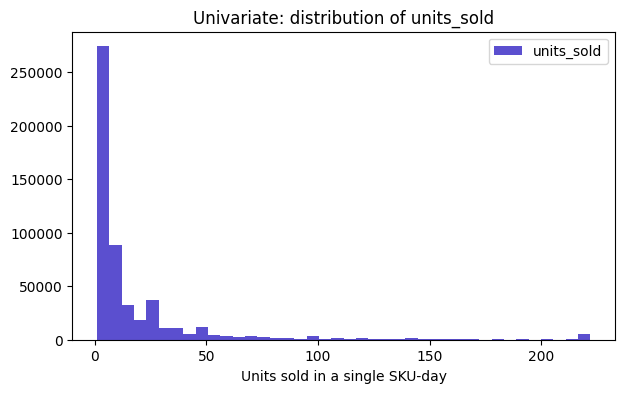


 category - value counts
category
General Merchandise     2446
Home & Decor             765
Kitchenware              526
Stationery & Cards       376
Bags & Accessories       268
Seasonal & Christmas     219
Toys & Games              67
Garden                    65
Name: count, dtype: int64


In [10]:
# Univariate Analysis
import matplotlib.pyplot as plt

sales = pd.read_csv("../data/processed/sales_daily.csv", parse_dates=["date"], dtype={"sku_id": str})
sku    = pd.read_csv("../data/processed/sku_master.csv", dtype={"sku_id": str})

# Univariate: units_sold (one column, by itself)
print("units_sold - single-column summary")
print(sales["units_sold"].describe())       # .describe() alone IS a univariate analysis - it summarizes ONE column.

fig, ax = plt.subplots(figsize = (7, 4))
ax.hist(sales["units_sold"].clip(upper=sales["units_sold"].quantile(0.99)), label = "units_sold", bins=40, color="#5B4FCF")
ax.set_title("Univariate: distribution of units_sold")
ax.set_xlabel("Units sold in a single SKU-day")
ax.legend()
plt.show()
# A histogram is the classic univariate chart - it only ever looks at ONE column's values and counts how often each range of values occurs

# Univariate: category (a text/categorical column, by itself)
print("\n category - value counts")
print(sku["category"].value_counts())
# For a TEXT column, "value_counts()" is the univariate equivalent of describe() - instead of mean/std (which don't make sense for text),
# it just counts how many times each distinct value appears


Correlation: unit_price vs units_sold
Correlation coefficient: -0.033


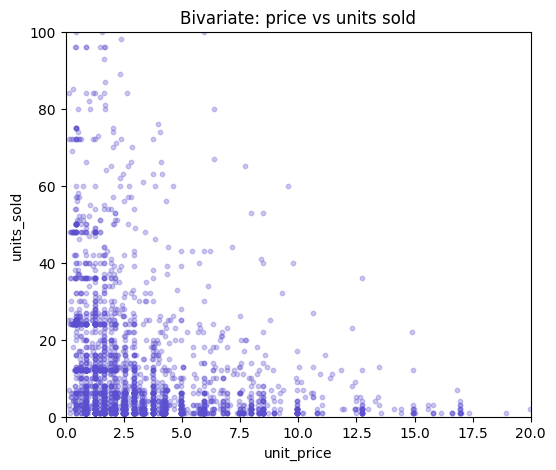


 Average units_sold, grouped by promo_flag
promo_flag
0    18.786474
1    47.152302
Name: units_sold, dtype: float64


In [ ]:
# Biavariate Analysis
# Bivariate: unit_price vs units_sold (does price relate to demand?)
print("Correlation: unit_price vs units_sold")
corr_value = sales[["unit_price", "units_sold"]].corr().iloc[0,1]
print(f"Correlation coefficient: {corr_value:.3f}")
# A correlation coefficient ranges from -1 to +1.
#  close to -1 = as one goes up, the other reliably goes DOWN
#  close to +1 = as one goes up, the other reliably goes UP too
#  close to 0  = no reliable straight-line relationship
# Economics theory predicts price and demand should be NEGATIVELY correlated (higher price -> people buy less) - this is a bivariate check on exactly TWO columns: price and quantity.

fig, ax = plt.subplots(figsize = (6, 5))
sample = sales.sample(3000, random_state=1)  # scatter all 530K points would be unreadable - sample instead
ax.scatter(sample["unit_price"], sample["units_sold"], alpha=0.3, s=10, color="#5B4FCF")
ax.set_xlim(0, 20)
ax.set_ylim(0, 100)
ax.set_xlabel("unit_price")
ax.set_ylabel("units_sold")
ax.set_title("Bivariate: price vs units sold")
plt.show()
# A scatter plot is the classic bivariate chart - every dot uses exactly TWO columns (one for x-position, one for y-position)

# Bivariate: promo_flag vs units_sold
print("\nAverage units_sold, grouped by promo_flag")
print(sales.groupby("promo_flag")["units_sold"].mean())
# groupby() here splits rows into two buckets (promo=0, promo=1) and
# computes the average of a SECOND column (units_sold) within each bucket that's bivariate: we're relating promo_flag to units_sold

In [8]:
# Loading the datasets
sales = pd.read_csv("../data/processed/sales_daily.csv", parse_dates= ["date"], dtype={"sku_id": str})
sku = pd.read_csv("../data/processed/sku_master.csv", dtype = {"sku_id": str})
cal = pd.read_csv("../data/processed/calendar.csv", parse_dates= ["date"])
inv = pd.read_csv("../data/processed/inventory_snapshots.csv", parse_dates=["date"], dtype={"sku_id": str})

In [9]:
# 1. Data Profiling

print("=== dtypes ===")
print(sales.dtypes)

print("\n=== nulls per column ===")
print(sales.isnull().sum().to_dict())       # should all be 0 after Week 1 cleaning

# duplicated(subset=...)
print("\nDuplicate (date, sku_id) pairs:", sales.duplicated(subset=["date", "sku_id"]).sum())

# sanity_checks: none of these should be physically possible in clean retail data
print("units_sold < 0:", (sales.units_sold < 0).sum())
print("revenue < 0:", (sales.revenue < 0).sum())
print("unit_price <= 0:", (sales.unit_price <= 0).sum())  # caught PADS here originally

print("\nDate range:", sales.date.min().date(), "to", sales.date.max().date())
print("Unique SKUs with sales:", sales.sku_id.nunique(), "/ sku_master rows:", len(sku))
# these two numbers should match - if sku_master has MORE rows than SKUs
# that ever sold, it means some SKUs exist in sku_master with zero sales


=== dtypes ===
date          datetime64[ns]
sku_id                object
units_sold             int64
revenue              float64
unit_price           float64
promo_flag             int64
dtype: object

=== nulls per column ===
{'date': 0, 'sku_id': 0, 'units_sold': 0, 'revenue': 0, 'unit_price': 0, 'promo_flag': 0}

Duplicate (date, sku_id) pairs: 0
units_sold < 0: 0
revenue < 0: 0
unit_price <= 0: 17

Date range: 2009-12-01 to 2011-12-09
Unique SKUs with sales: 4732 / sku_master rows: 4732


C:\Users\Sami\AppData\Local\Temp\ipykernel_23308\3051726499.py:13: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  axes[0].hist(sku_totals.clip(upper=sku_totals.quantile(0.95)), bins=40, color="#5B4FCF")


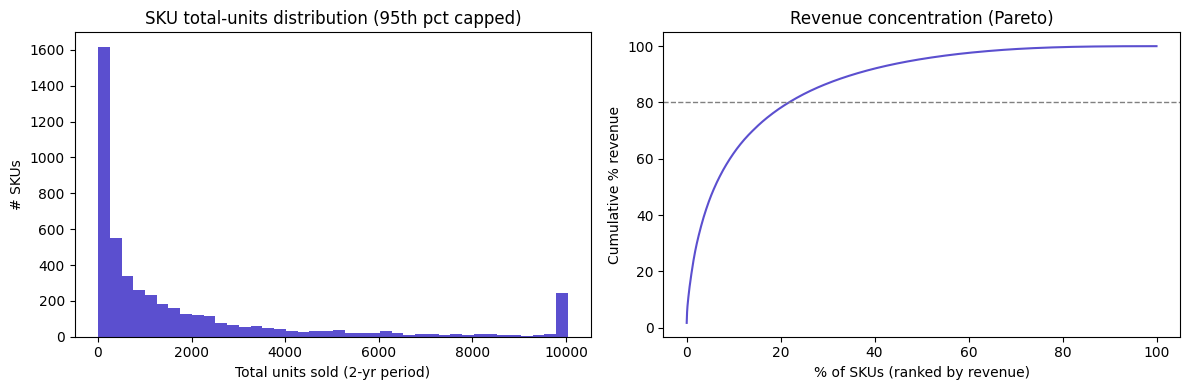

Median SKU total units: 650 | Max: 106,139
21.7% of SKUs drive 80% of revenue


In [12]:
# 2. Demand Distribution & Revenue Concentration (Pareto) - 80/20 rule
# WHY: retail demand is almost never a symmetric bell curve — a handful of
# SKUs usually account for most revenue, and this shapes both which metric
# we should trust (WAPE, not MAPE) and which SKUs deserve forecasting effort.

sku_totals = sales.groupby("sku_id")["units_sold"].sum().sort_values(ascending=False)
rev_by_sku = sales.groupby("sku_id")["revenue"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# x-axis scale, so one huge SKU doesn't squash the whole histogram into
# one bar. We are NOT removing the outlier from the actual data here.
axes[0].hist(sku_totals.clip(upper=sku_totals.quantile(0.95)), bins=40, color="#5B4FCF")
axes[0].set_title("SKU total-units distribution (95th pct capped)")
axes[0].set_xlabel("Total units sold (2-yr period)")
axes[0].set_ylabel("# SKUs")

# cumulative revenue share vs cumulative SKU share = the Pareto/Lorenz curve.
# Ranking SKUs by revenue (highest first) and walking the cumulative sum
# tells us: "the top X% of SKUs account for Y% of revenue"
cum_share = (rev_by_sku.cumsum() / rev_by_sku.sum()).values
sku_share = np.arange(1, len(rev_by_sku) + 1) / len(rev_by_sku) * 100
axes[1].plot(sku_share, cum_share * 100, color="#5B4FCF")
axes[1].axhline(80, color="grey", linestyle="--", linewidth=1)  # reference line at 80%
axes[1].set_xlabel("% of SKUs (ranked by revenue)")
axes[1].set_ylabel("Cumulative % revenue")
axes[1].set_title("Revenue concentration (Pareto)")
plt.tight_layout()
plt.show()

# find where the curve crosses 80% — that's our "X% of SKUs drive 80% of revenue" number
pct_for_80 = (cum_share <= 0.80).sum() / len(cum_share) * 100
print(f"Median SKU total units: {sku_totals.median():.0f} | Max: {sku_totals.max():,.0f}")
print(f"{pct_for_80:.1f}% of SKUs drive 80% of revenue")

Median zero-demand rate: 81.6%
25th / 75th percentile: 59.8% / 91.8%


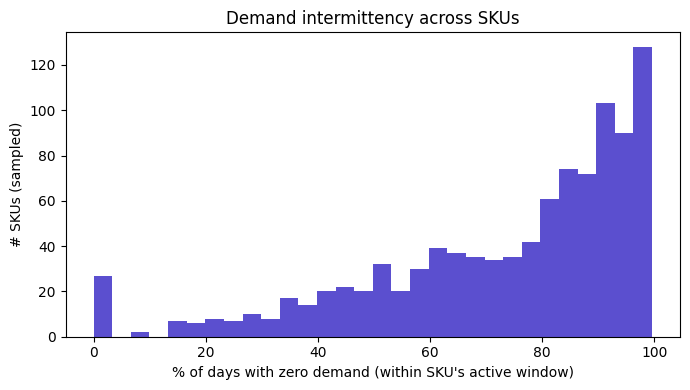

In [13]:
# 3. Zero-Demand Days / Demand Intermittency

# WHY: sales_daily is a SPARSE fact table - it only has rows for days, a sale actually happened. To see how often a SKU has ZERO demand (not just "low"),
# we have to reconstruct the full daily calendar for each SKU's own active window and count the missing days. This matters because intermittent 
# demand (frequent zeros) needs different modelling treatment than steady daily demand, and it's the real justification for WAPE over MAPE.

active_window = sales.groupby("sku_id")["date"].agg(["min", "max"])

# sampling 1000 SKUs instead of all 4,731 — this loop is O(n) per SKU and
# doing it on the full catalog would be slow for no extra insight; 800 is
# large enough to be statistically representative
rng = np.random.default_rng(42)  # fixed seed = reproducible sample every run
sample_skus = rng.choice(sales.sku_id.unique(), size=min(1000, sales.sku_id.nunique()), replace=False)

intermittency = {}
for s in sample_skus:
    low, high = active_window.loc[s, "min"], active_window.loc[s, "max"]
    window = pd.date_range(low, high, freq="D")     # every calendar day this SKU was "alive"
    sold_days = set(sales.loc[sales.sku_id == s, "date"])  # days it actually sold something
    zero_days = len(window) - len(sold_days & set(window))
    intermittency[s] = zero_days / len(window)          # fraction of active days with zero sales

interm = pd.Series(intermittency)
print(f"Median zero-demand rate: {interm.median()*100:.1f}%")
print(f"25th / 75th percentile: {interm.quantile(.25)*100:.1f}% / {interm.quantile(.75)*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(interm * 100, bins=30, color="#5B4FCF")
ax.set_xlabel("% of days with zero demand (within SKU's active window)")
ax.set_ylabel("# SKUs (sampled)")
ax.set_title("Demand intermittency across SKUs")
plt.tight_layout()
plt.show()


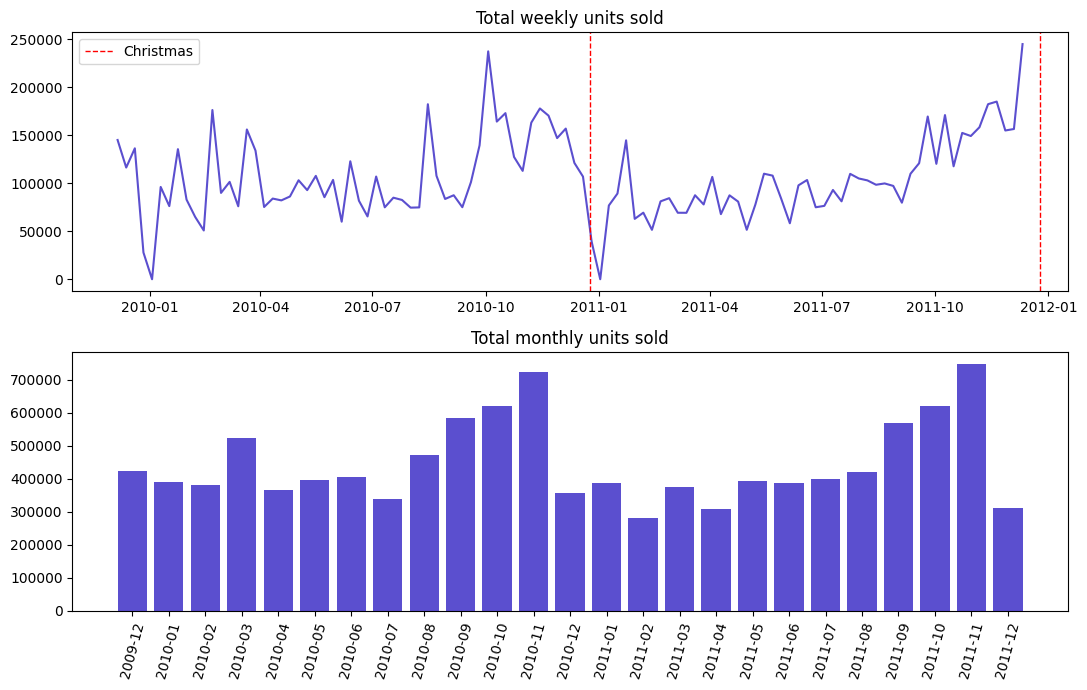

Units sold by month, year-over-year:
year           2009      2010      2011
month_num                              
1               NaN  390417.0  386741.0
2               NaN  381627.0  282630.0
3               NaN  525046.0  376183.0
4               NaN  366072.0  307656.0
5               NaN  395442.0  394657.0
6               NaN  406240.0  388129.0
7               NaN  337560.0  399292.0
8               NaN  471939.0  420701.0
9               NaN  583369.0  568702.0
10              NaN  619515.0  619598.0
11              NaN  724268.0  746952.0
12         425226.0  357531.0  312648.0


In [14]:
# 4. TREND — WEEKLY / MONTHLY / YEAR-OVER-YEAR
# WHY: before picking a baseline model, we need to know if there's real,
# REPEATABLE seasonality (worth building a seasonal-naive baseline around)
# or if patterns are one-off noise.

# pd.Grouper(freq="W") buckets every transaction into its calendar week
# and sums units_sold within each bucket - turns a daily series into weekly
weekly  = sales.groupby(pd.Grouper(key="date", freq="W"))["units_sold"].sum()
monthly = sales.groupby(pd.Grouper(key="date", freq="MS"))["units_sold"].sum()  # MS = month start

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
axes[0].plot(weekly.index, weekly.values, color="#5B4FCF")
axes[0].axvline(pd.Timestamp("2010-12-25"), color="red", ls="--", lw=1)
axes[0].axvline(pd.Timestamp("2011-12-25"), color="red", ls="--", lw=1, label="Christmas")
axes[0].set_title("Total weekly units sold")
axes[0].legend()

axes[1].bar(monthly.index.strftime("%Y-%m"), monthly.values, color="#5B4FCF")
axes[1].set_title("Total monthly units sold")
axes[1].tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()

# pivot month-by-month across years side by side - this is how we PROVE
# seasonality repeats, rather than just eyeballing one squiggly line
sales["month_num"] = sales["date"].dt.month
sales["year"] = sales["date"].dt.year
yoy = sales.groupby(["year", "month_num"])["units_sold"].sum().unstack(level=0)
print("Units sold by month, year-over-year:")
print(yoy)


                         revenue    units  skus  revenue_per_sku
category                                                        
General Merchandise   8892446.84  4559531  2446           3636.0
Kitchenware           3006526.28  1829282   526           5716.0
Home & Decor          2957454.69  1566488   765           3866.0
Bags & Accessories    2147488.68  1284809   268           8013.0
Stationery & Cards    1212035.45  1123765   376           3223.0
Seasonal & Christmas   887456.32   580379   219           4052.0
Toys & Games           314827.75   160400    67           4699.0
Garden                 227381.78    83487    65           3498.0


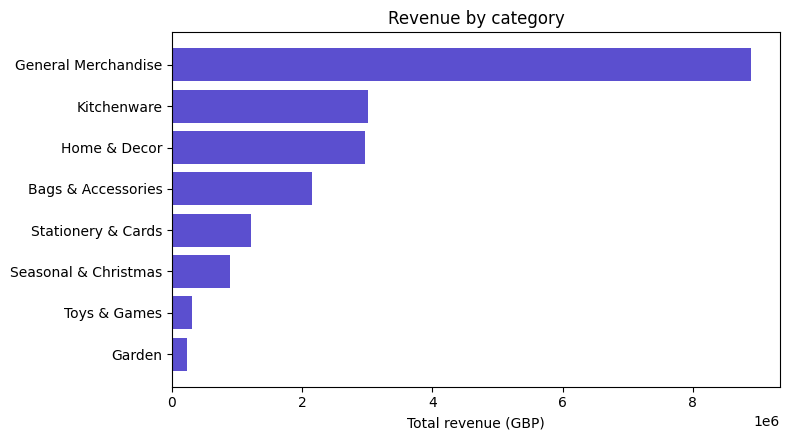

In [15]:
# 5. CATEGORY PERFORMANCE
# WHY: our category field is a keyword-derived assumption (Week 1), not
# ground truth — checking revenue/units by category both gives a business
# insight AND is a second sanity check on that categorization logic.

cat_perf = (sales.merge(sku[["sku_id", "category"]], on="sku_id")
                  .groupby("category")
                  .agg(revenue=("revenue", "sum"),
                       units=("units_sold", "sum"),
                       skus=("sku_id", "nunique"))
                  .sort_values("revenue", ascending=False))
cat_perf["revenue_per_sku"] = (cat_perf["revenue"] / cat_perf["skus"]).round(0)
print(cat_perf)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(cat_perf.index[::-1], cat_perf["revenue"].values[::-1], color="#5B4FCF")
ax.set_xlabel("Total revenue (GBP)")
ax.set_title("Revenue by category")
plt.tight_layout()
plt.show()

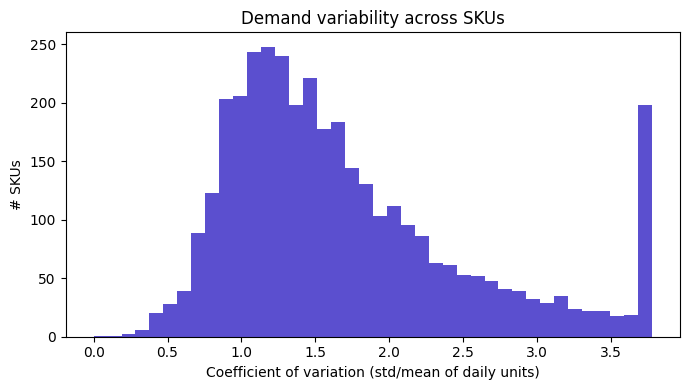

Median CV: 1.49
SKUs with CV > 2 (highly volatile): 1033 (28.2% of SKUs with enough history)


In [ ]:
# 6. DEMAND VARIABILITY (Coefficient of Variation)
# WHY: two SKUs can have the SAME average demand but very different
# volatility. High-volatility SKUs are harder to forecast accurately and
# need bigger safety stock - this feeds directly into Week 3's risk scoring.
# CV = std / mean: a unitless measure of "how spread out is this, relative
# to its own average" — lets us compare volatility fairly across SKUs that
# sell in totally different volumes.

sku_stats = sales.groupby("sku_id")["units_sold"].agg(["mean", "std", "count"])
sku_stats = sku_stats[sku_stats["count"] >= 20]   # need enough data points to trust a std estimate
sku_stats["cv"] = sku_stats["std"] / sku_stats["mean"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sku_stats["cv"].clip(upper=sku_stats["cv"].quantile(0.95)), bins=40, color="#5B4FCF")
ax.set_xlabel("Coefficient of variation (std/mean of daily units)")
ax.set_ylabel("# SKUs")
ax.set_title("Demand variability across SKUs")
plt.tight_layout()
plt.show()

print(f"Median CV: {sku_stats['cv'].median():.2f}")
print(f"SKUs with CV > 2 (highly volatile): {(sku_stats['cv']>2).sum()} "
      f"({(sku_stats['cv']>2).mean()*100:.1f}% of SKUs with enough history)")

In [17]:
# 7. CORRELATION / DEMAND-DRIVER ANALYSIS
# WHY: confirms our engineered/inferred signals (promo_flag especially,
# since it's a heuristic guess, not observed truth) actually relate to
# demand the way theory predicts, BEFORE we trust them as model features.

sales_cal = sales.merge(cal[["date", "is_holiday", "season"]], on="date", how="left")
sales_cal["dow"] = sales_cal["date"].dt.dayofweek  # 0=Monday ... 6=Sunday

corr = sales_cal[["units_sold", "unit_price", "promo_flag", "is_holiday", "dow"]].corr()
print(corr.round(3))
# NOTE: if a column shows NaN here, it usually means that column has ZERO
# VARIANCE in this subset (a constant can't correlate with anything) —
# check that before assuming it's a bug. That's exactly what happened with
# is_holiday: literally zero sales rows fall on any UK holiday date.

promo_lift = sales[sales.promo_flag == 1].units_sold.mean() / sales[sales.promo_flag == 0].units_sold.mean() - 1
print(f"\nPromo lift: {promo_lift*100:.1f}% higher avg demand on promo days")

price_corr = sales_cal[["unit_price", "units_sold"]].corr().iloc[0, 1]
print(f"Price vs units_sold correlation: {price_corr:.3f} (negative = expected demand curve)")

            units_sold  unit_price  promo_flag  is_holiday    dow
units_sold       1.000      -0.033       0.043         NaN -0.012
unit_price      -0.033       1.000      -0.081         NaN -0.033
promo_flag       0.043      -0.081       1.000         NaN  0.031
is_holiday         NaN         NaN         NaN         NaN    NaN
dow             -0.012      -0.033       0.031         NaN  1.000

Promo lift: 151.0% higher avg demand on promo days
Price vs units_sold correlation: -0.033 (negative = expected demand curve)


In [18]:
# 8. DEAD STOCK
# WHY: directly answers one of the brief's four core business asks —
# "which products are overstocked so we can clear them." A SKU that sold
# meaningfully in the past but has gone silent recently is locked-up cash.

last_sale    = sales.groupby("sku_id")["date"].max()
total_units  = sales.groupby("sku_id")["units_sold"].sum()
end_date     = sales["date"].max()

dead = pd.DataFrame({
    "last_sale": last_sale,
    "days_since_last_sale": (end_date - last_sale).dt.days,
    "total_units_ever_sold": total_units,
})
# thresholds are a judgment call, documented as such: "meaningful past sales"
# (>=20 units) AND "quiet recently" (90+ days silent)
dead_stock = dead[(dead.days_since_last_sale > 90) & (dead.total_units_ever_sold >= 20)]
print(f"Dead-stock SKUs: {len(dead_stock):,} ({len(dead_stock)/sales.sku_id.nunique()*100:.1f}% of active SKUs)")
print(dead_stock.sort_values("total_units_ever_sold", ascending=False).head(5))

Dead-stock SKUs: 1,260 (26.6% of active SKUs)
        last_sale  days_since_last_sale  total_units_ever_sold
sku_id                                                        
37410  2010-04-07                   611                  25707
84270  2010-12-06                   368                  22936
16033  2011-02-17                   295                  15121
21085  2010-07-12                   515                  13731
21091  2010-03-18                   631                  13700


In [19]:
# 9. SIMULATED STOCKOUT CHECK
# WHY: inventory_snapshots is SIMULATED (Week 1, since real inventory data
# doesn't exist in this source). We can't validate it against reality, but
# we CAN check it behaves the way real inventory dynamics should — e.g.
# volatile-demand SKUs should stock out more often than stable ones, since
# the same safety stock buffer is harder to hold against unpredictable demand.

inv_check = inv.copy()
inv_check["is_stockout_snapshot"] = inv_check["on_hand_units"] <= 0
stockout_rate = inv_check.groupby("sku_id")["is_stockout_snapshot"].mean()

print(f"Median simulated stockout rate: {stockout_rate.median()*100:.1f}% of snapshots")

top_cv_skus = sku_stats.sort_values("cv", ascending=False).head(200).index
print(f"Avg stockout rate, 200 highest-CV SKUs: {stockout_rate.reindex(top_cv_skus).mean()*100:.1f}% "
      f"vs overall avg {stockout_rate.mean()*100:.1f}%")
# if the high-CV group's rate is meaningfully HIGHER than the overall average,
# that's the simulation behaving sensibly — a real sanity check, not proof,
# since this table isn't real client data

Median simulated stockout rate: 2.3% of snapshots
Avg stockout rate, 200 highest-CV SKUs: 17.5% vs overall avg 28.1%
